In [5]:
pip install pandas requests matplotlib seaborn scikit-learn


In [6]:
import pandas as pd

# Load raw delinquency data
raw_delinquency = pd.read_csv("raw_data/delinquency_consumer.csv")

# Display first 10 rows
raw_delinquency.head(10)


,realtime_start,realtime_end,date,value
0,2026-02-25,2026-02-25,1991-01-01,5.26
1,2026-02-25,2026-02-25,1991-04-01,5.48
2,2026-02-25,2026-02-25,1991-07-01,5.35
3,2026-02-25,2026-02-25,1991-10-01,5.32
4,2026-02-25,2026-02-25,1992-01-01,5.27
5,2026-02-25,2026-02-25,1992-04-01,5.10
6,2026-02-25,2026-02-25,1992-07-01,4.98
7,2026-02-25,2026-02-25,1992-10-01,4.69
8,2026-02-25,2026-02-25,1993-01-01,4.60
9,2026-02-25,2026-02-25,1993-04-01,4.46


In [7]:
# Load raw charge-off data
raw_chargeoff = pd.read_csv("raw_data/chargeoff_consumer.csv")

# Display first 10 rows
raw_chargeoff.head(10)


,realtime_start,realtime_end,date,value
0,2026-03-01,2026-03-01,1985-01-01,1.90
1,2026-03-01,2026-03-01,1985-04-01,2.26
2,2026-03-01,2026-03-01,1985-07-01,2.67
3,2026-03-01,2026-03-01,1985-10-01,2.91
4,2026-03-01,2026-03-01,1986-01-01,3.13
5,2026-03-01,2026-03-01,1986-04-01,3.20
6,2026-03-01,2026-03-01,1986-07-01,3.39
7,2026-03-01,2026-03-01,1986-10-01,3.39
8,2026-03-01,2026-03-01,1987-01-01,3.45
9,2026-03-01,2026-03-01,1987-04-01,3.34


In [8]:
import pandas as pd

clean_df = pd.read_csv("clean_data/banking_system_indicators.csv")

clean_df.head(10)


,date,delinquency_consumer,chargeoff_consumer,delinquency_business,total_bank_credit,federal_funds_rate,treasury_10y,treasury_2y,financial_stress_index,unemployment_rate
0,1948-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.4
1,1948-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.8
2,1948-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
3,1948-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.9
4,1948-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5
5,1948-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.6
6,1948-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.6
7,1948-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.9
8,1948-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.8
9,1948-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7


In [9]:
import requests
import pandas as pd

API_KEY = "df78890f2959f8c083e5256ad0ff3817"

url = "https://api.stlouisfed.org/fred/series/observations"
params = {
    "series_id": "DRCCLACBS",   # Delinquency Rate on Consumer Loans
    "api_key": API_KEY,
    "file_type": "json"
}

response = requests.get(url, params=params)

data = response.json()
df = pd.DataFrame(data["observations"])

df.head()


,realtime_start,realtime_end,date,value
0,2026-02-25,2026-02-25,1991-01-01,5.26
1,2026-02-25,2026-02-25,1991-04-01,5.48
2,2026-02-25,2026-02-25,1991-07-01,5.35
3,2026-02-25,2026-02-25,1991-10-01,5.32
4,2026-02-25,2026-02-25,1992-01-01,5.27


In [10]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Convert value column to numeric (force errors to NaN)
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Check for missing values
df.isna().sum()


realtime_start    0
realtime_end      0
date              0
value             0
dtype: int64

In [11]:
df.tail()


,realtime_start,realtime_end,date,value
135,2026-02-25,2026-02-25,2024-10-01,3.08
136,2026-02-25,2026-02-25,2025-01-01,3.06
137,2026-02-25,2026-02-25,2025-04-01,3.04
138,2026-02-25,2026-02-25,2025-07-01,2.98
139,2026-02-25,2026-02-25,2025-10-01,2.94


In [12]:
df.to_csv("raw_delinquency_consumer.csv", index=False)


In [13]:
def fetch_fred_series(series_id):
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    data = response.json()
    df = pd.DataFrame(data["observations"])
    
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    
    return df


In [14]:
df_chargeoff = fetch_fred_series("CORCCACBS")
df_chargeoff.head()


,realtime_start,realtime_end,date,value
0,2026-04-02,2026-04-02,1985-01-01,1.90
1,2026-04-02,2026-04-02,1985-04-01,2.26
2,2026-04-02,2026-04-02,1985-07-01,2.67
3,2026-04-02,2026-04-02,1985-10-01,2.91
4,2026-04-02,2026-04-02,1986-01-01,3.13


In [15]:
df_chargeoff.to_csv("raw_chargeoff_consumer.csv", index=False)


In [16]:
fred_series = {
    "delinquency_consumer": "DRCCLACBS",
    "chargeoff_consumer": "CORCCACBS",
    "delinquency_business": "DRCLACBS",
    "total_bank_credit": "TOTBKCR",
    "federal_funds_rate": "FEDFUNDS",
    "treasury_10y": "DGS10",
    "treasury_2y": "DGS2",
    "financial_stress_index": "STLFSI4",
    "unemployment_rate": "UNRATE"
}


In [17]:
import os
os.makedirs("raw_data", exist_ok=True)
os.makedirs("clean_data", exist_ok=True)


In [18]:
raw_datasets = {}

for name, series_id in fred_series.items():
    print(f"Fetching {name} ({series_id})...")
    
    df_temp = fetch_fred_series(series_id)
    
    # Save raw version
    df_temp.to_csv(f"raw_data/{name}.csv", index=False)
    
    raw_datasets[name] = df_temp
    
    print(f"Saved raw_data/{name}.csv")


Fetching delinquency_consumer (DRCCLACBS)...
Saved raw_data/delinquency_consumer.csv
Fetching chargeoff_consumer (CORCCACBS)...
Saved raw_data/chargeoff_consumer.csv
Fetching delinquency_business (DRCLACBS)...
Saved raw_data/delinquency_business.csv
Fetching total_bank_credit (TOTBKCR)...
Saved raw_data/total_bank_credit.csv
Fetching federal_funds_rate (FEDFUNDS)...
Saved raw_data/federal_funds_rate.csv
Fetching treasury_10y (DGS10)...
Saved raw_data/treasury_10y.csv
Fetching treasury_2y (DGS2)...
Saved raw_data/treasury_2y.csv
Fetching financial_stress_index (STLFSI4)...
Saved raw_data/financial_stress_index.csv
Fetching unemployment_rate (UNRATE)...
Saved raw_data/unemployment_rate.csv


In [19]:
merged_df = None

for name, df_temp in raw_datasets.items():
    df_temp = df_temp[["date", "value"]].rename(columns={"value": name})
    
    if merged_df is None:
        merged_df = df_temp
    else:
        merged_df = pd.merge(merged_df, df_temp, on="date", how="outer")


In [20]:
merged_df = merged_df.sort_values("date").reset_index(drop=True)

merged_df.head()
merged_df.tail()


,date,delinquency_consumer,chargeoff_consumer,delinquency_business,total_bank_credit,federal_funds_rate,treasury_10y,treasury_2y,financial_stress_index,unemployment_rate
17147,2026-03-26,NaN,NaN,NaN,NaN,NaN,4.42,3.96,NaN,NaN
17148,2026-03-27,NaN,NaN,NaN,NaN,NaN,4.44,3.88,-0.1828,NaN
17149,2026-03-30,NaN,NaN,NaN,NaN,NaN,4.35,3.82,NaN,NaN
17150,2026-03-31,NaN,NaN,NaN,NaN,NaN,4.30,3.79,NaN,NaN
17151,2026-04-01,NaN,NaN,NaN,NaN,NaN,4.33,3.81,NaN,NaN


In [21]:
merged_df.isna().sum()


date                          0
delinquency_consumer      17012
chargeoff_consumer        16988
delinquency_business      16996
total_bank_credit         14375
federal_funds_rate        16291
treasury_10y               1106
treasury_2y                4698
financial_stress_index    15469
unemployment_rate         16215
dtype: int64

In [22]:
merged_df.to_csv("clean_data/banking_system_indicators.csv", index=False)


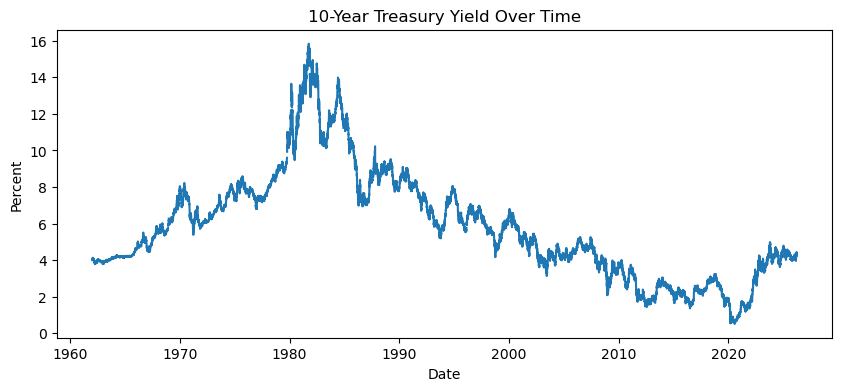

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(merged_df["date"], merged_df["treasury_10y"])
plt.title("10-Year Treasury Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


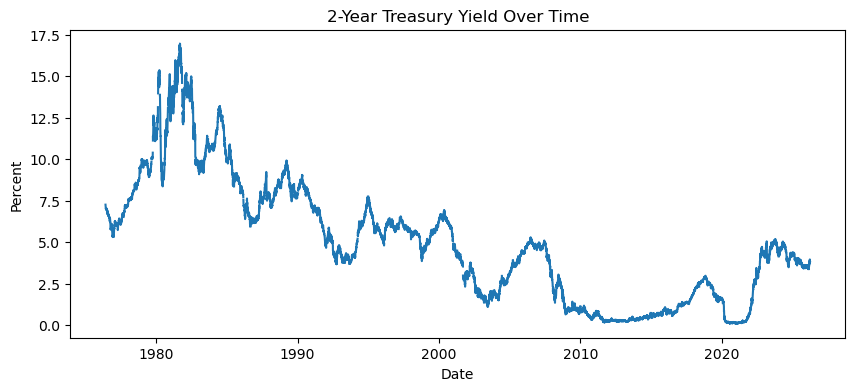

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(merged_df["date"], merged_df["treasury_2y"])
plt.title("2-Year Treasury Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


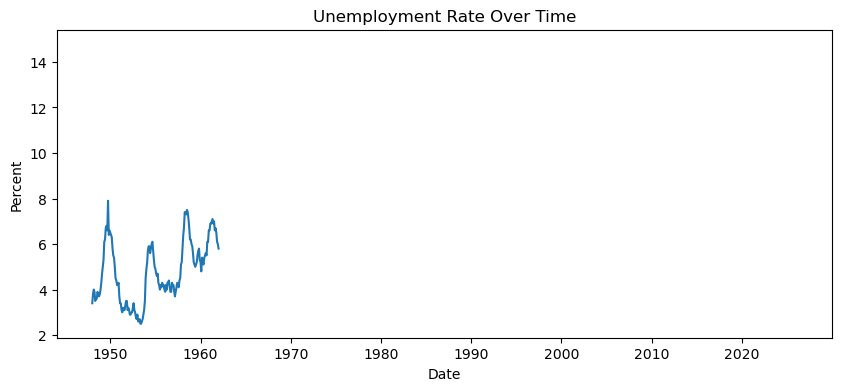

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(merged_df["date"], merged_df["unemployment_rate"])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


In [26]:

df_delinquency = pd.read_csv("raw_data/delinquency_consumer.csv")
df_delinquency["date"] = pd.to_datetime(df_delinquency["date"])


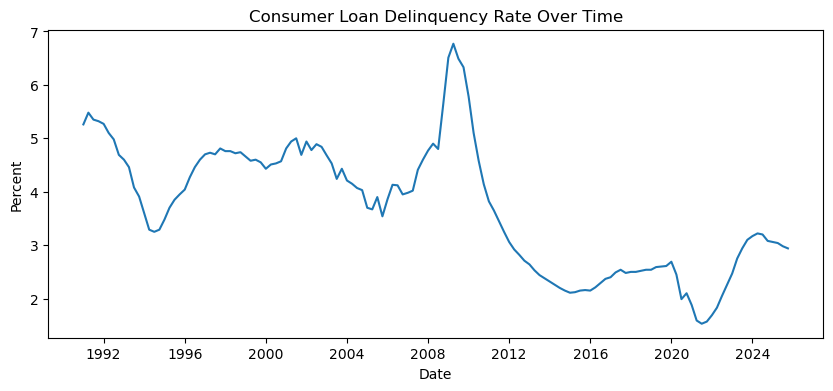

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(df_delinquency["date"], df_delinquency["value"])
plt.title("Consumer Loan Delinquency Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


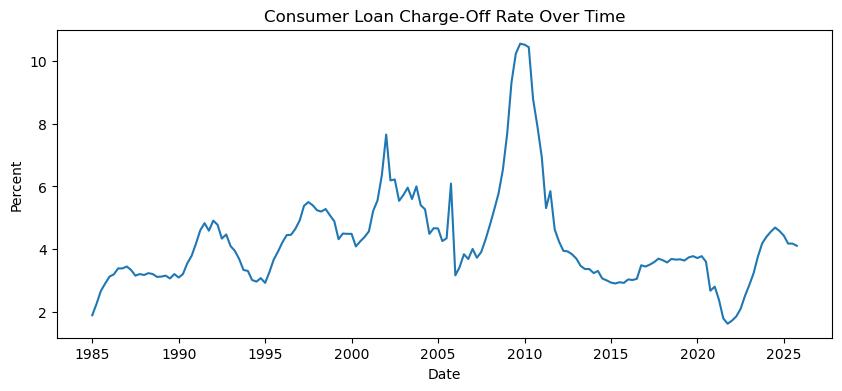

In [28]:
df_chargeoff = pd.read_csv("raw_data/chargeoff_consumer.csv")
df_chargeoff["date"] = pd.to_datetime(df_chargeoff["date"])

plt.figure(figsize=(10, 4))
plt.plot(df_chargeoff["date"], df_chargeoff["value"])
plt.title("Consumer Loan Charge-Off Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


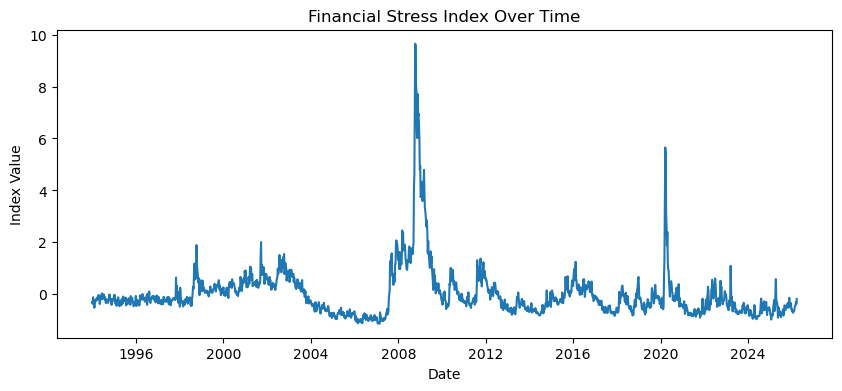

In [29]:
df_stress = pd.read_csv("raw_data/financial_stress_index.csv")
df_stress["date"] = pd.to_datetime(df_stress["date"])

plt.figure(figsize=(10, 4))
plt.plot(df_stress["date"], df_stress["value"])
plt.title("Financial Stress Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()


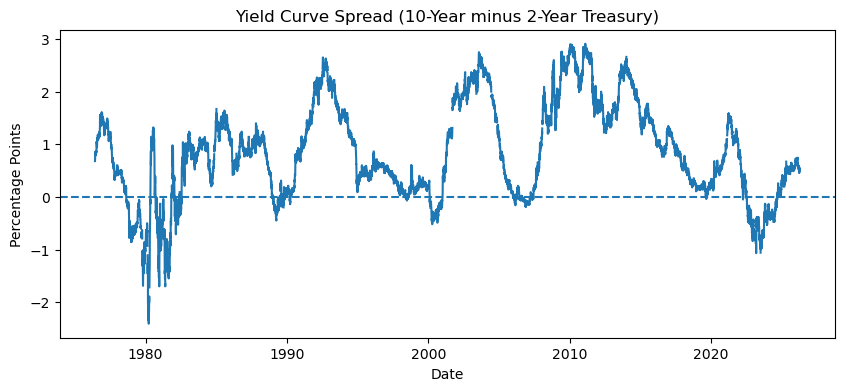

In [30]:
merged_df["yield_spread"] = merged_df["treasury_10y"] - merged_df["treasury_2y"]
plt.figure(figsize=(10, 4))
plt.plot(merged_df["date"], merged_df["yield_spread"])
plt.axhline(0, linestyle="--")
plt.title("Yield Curve Spread (10-Year minus 2-Year Treasury)")
plt.xlabel("Date")
plt.ylabel("Percentage Points")
plt.show()


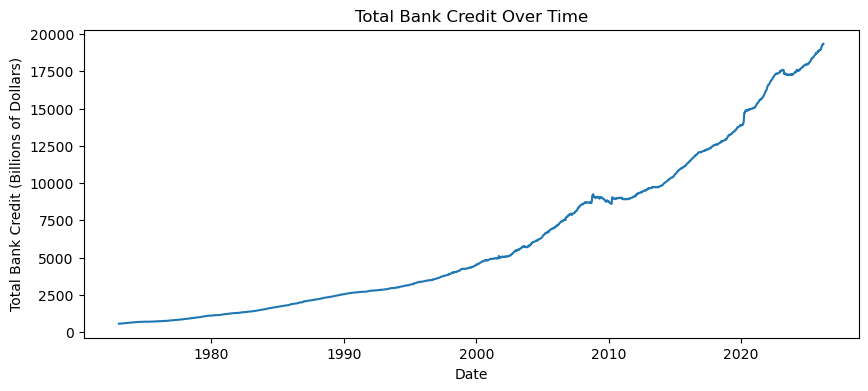

In [31]:
df_credit = pd.read_csv("raw_data/total_bank_credit.csv")
df_credit["date"] = pd.to_datetime(df_credit["date"])
plt.figure(figsize=(10, 4))
plt.plot(df_credit["date"], df_credit["value"])
plt.title("Total Bank Credit Over Time")
plt.xlabel("Date")
plt.ylabel("Total Bank Credit (Billions of Dollars)")
plt.show()


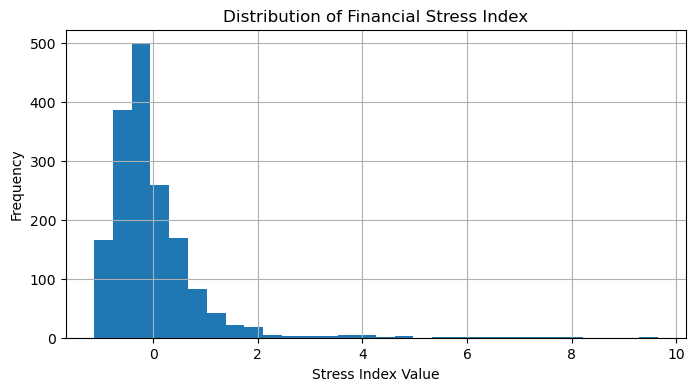

In [32]:
plt.figure(figsize=(8, 4))
merged_df["financial_stress_index"].dropna().hist(bins=30)
plt.title("Distribution of Financial Stress Index")
plt.xlabel("Stress Index Value")
plt.ylabel("Frequency")
plt.show()


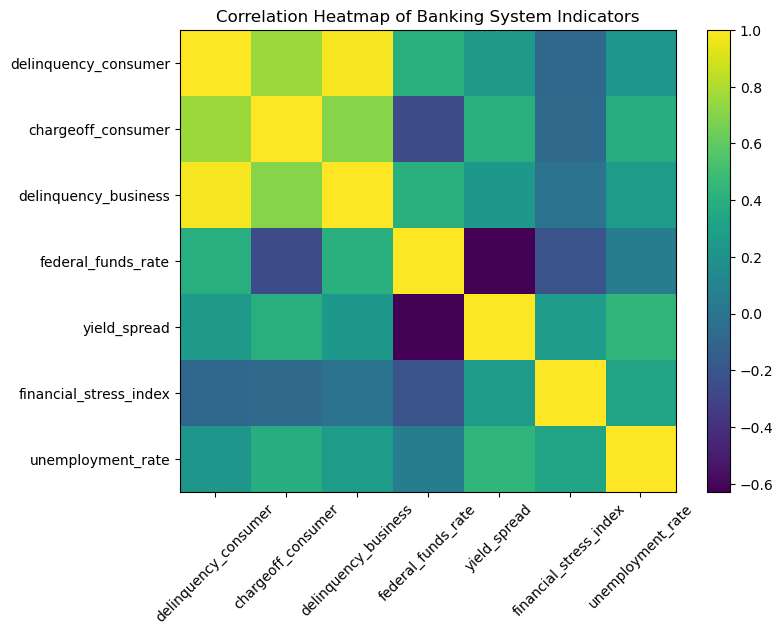

In [33]:
corr_df = merged_df[[
    "delinquency_consumer",
    "chargeoff_consumer",
    "delinquency_business",
    "federal_funds_rate",
    "yield_spread",
    "financial_stress_index",
    "unemployment_rate"
]]
corr_matrix = corr_df.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Banking System Indicators")
plt.show()



In [34]:
#***********************************************************************************************************************

In [35]:
#Module 2

In [36]:
import pandas as pd
import numpy as np

df = merged_df.copy()

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df = df.fillna(method="ffill").dropna()

print(df.isna().sum())

date                      0
delinquency_consumer      0
chargeoff_consumer        0
delinquency_business      0
total_bank_credit         0
federal_funds_rate        0
treasury_10y              0
treasury_2y               0
financial_stress_index    0
unemployment_rate         0
yield_spread              0
dtype: int64


C:\Users\Sreek\AppData\Local\Temp\ipykernel_44428\3342655725.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill").dropna()


In [37]:
# Remove date column for modeling
numeric_df = df.drop(columns=["date"])

print("Columns used for modeling:")
print(numeric_df.columns)

Columns used for modeling:
Index(['delinquency_consumer', 'chargeoff_consumer', 'delinquency_business',
       'total_bank_credit', 'federal_funds_rate', 'treasury_10y',
       'treasury_2y', 'financial_stress_index', 'unemployment_rate',
       'yield_spread'],
      dtype='object')


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)

scaled_df.head()

,delinquency_consumer,chargeoff_consumer,delinquency_business,total_bank_credit,federal_funds_rate,treasury_10y,treasury_2y,financial_stress_index,unemployment_rate,yield_spread
0,0.281852,-0.663682,0.060944,-1.366807,0.156536,1.183983,0.631125,-0.294496,0.543483,0.687977
1,0.015522,-0.681373,-0.075415,-1.366807,0.197092,1.183983,0.631125,-0.294496,0.599727,0.687977
2,0.015522,-0.681373,-0.075415,-1.366807,0.197092,1.238337,0.654847,-0.294496,0.599727,0.731643
3,0.015522,-0.681373,-0.075415,-1.366807,0.197092,1.214180,0.650103,-0.294496,0.599727,0.698893
4,0.015522,-0.681373,-0.075415,-1.363822,0.197092,1.226258,0.659592,-0.294496,0.599727,0.698893


In [39]:
from sklearn.decomposition import PCA

# PCA 2 Components
pca_2 = PCA(n_components=2)
pca_2_components = pca_2.fit_transform(scaled_data)

# PCA 3 Components
pca_3 = PCA(n_components=3)
pca_3_components = pca_3.fit_transform(scaled_data)

print("Explained Variance (3 Components):")
print(pca_3.explained_variance_ratio_)

print("Cumulative Variance:")
print(np.cumsum(pca_3.explained_variance_ratio_))

Explained Variance (3 Components):
[0.41727051 0.36468993 0.08860304]
Cumulative Variance:
[0.41727051 0.78196044 0.87056348]


In [40]:
pca_full = PCA()
pca_full.fit(scaled_data)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components needed for 95% variance:", components_95)

Components needed for 95% variance: 5


In [41]:
eigenvalues = pca_full.explained_variance_

print("Top 3 Eigenvalues:")
print(eigenvalues[:3])

Top 3 Eigenvalues:
[4.17319458 3.64732706 0.88613438]


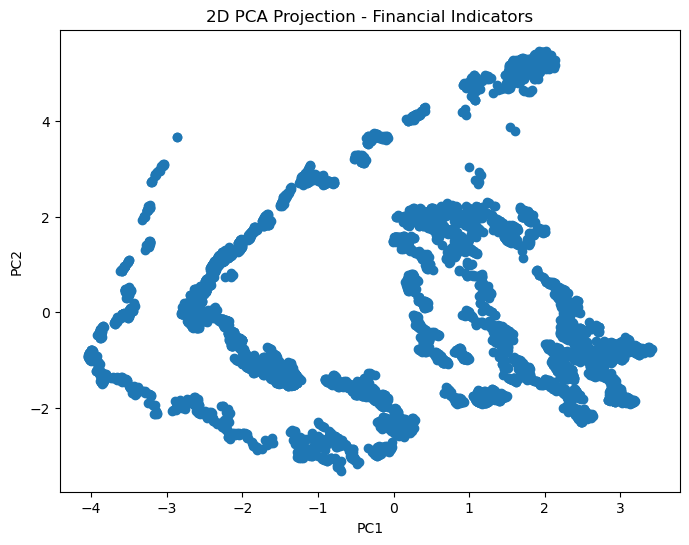

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pca_2_components[:,0], pca_2_components[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection - Financial Indicators")
plt.show()

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores[k] = score

print("Silhouette Scores:")
print(silhouette_scores)

# Top 3 k values
optimal_ks = sorted(silhouette_scores, key=silhouette_scores.get, reverse=True)[:3]

print("Top 3 optimal k values:", optimal_ks)


Silhouette Scores:
{2: 0.35372468658925704, 3: 0.40774318172493945, 4: 0.40985588733383993, 5: 0.395341361089666, 6: 0.33449702478231397, 7: 0.3827310690767006, 8: 0.36474135598666124, 9: 0.3942164531057981}
Top 3 optimal k values: [4, 3, 5]


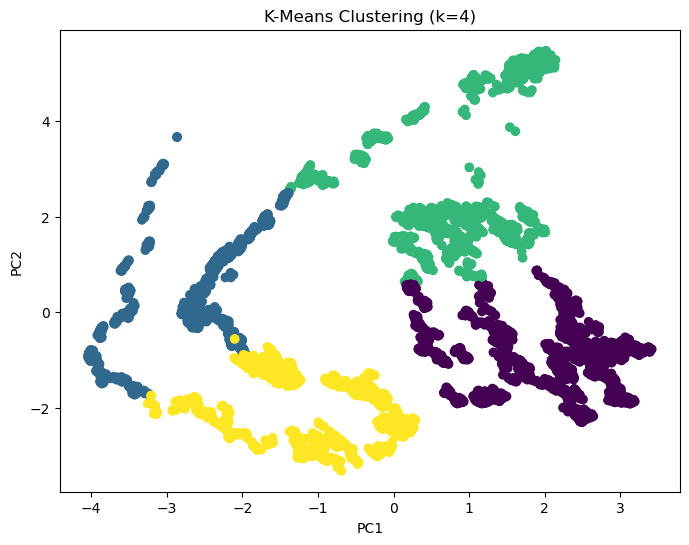

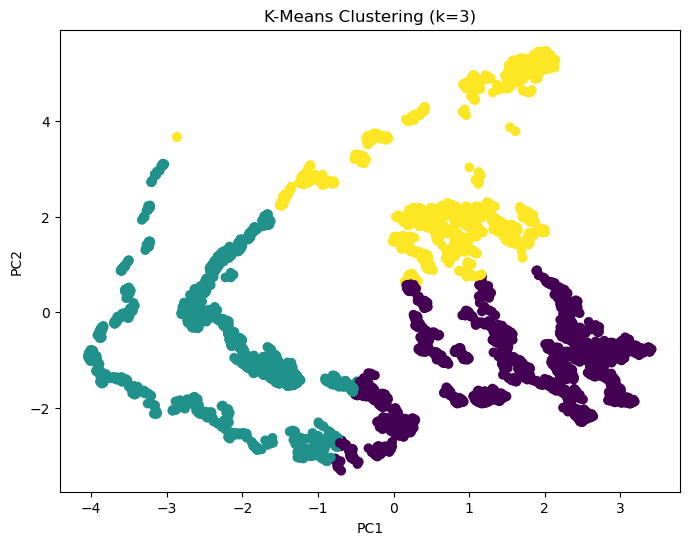

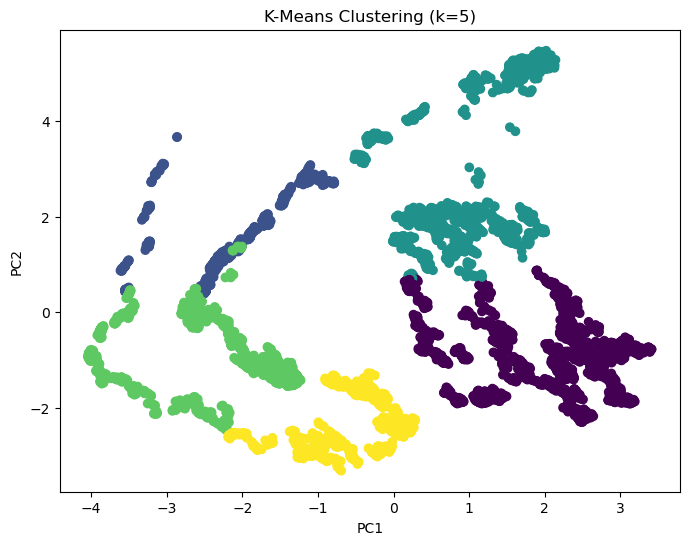

In [44]:
for k in optimal_ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)

    plt.figure(figsize=(8,6))
    plt.scatter(pca_2_components[:,0], pca_2_components[:,1], c=labels)
    plt.title(f"K-Means Clustering (k={k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

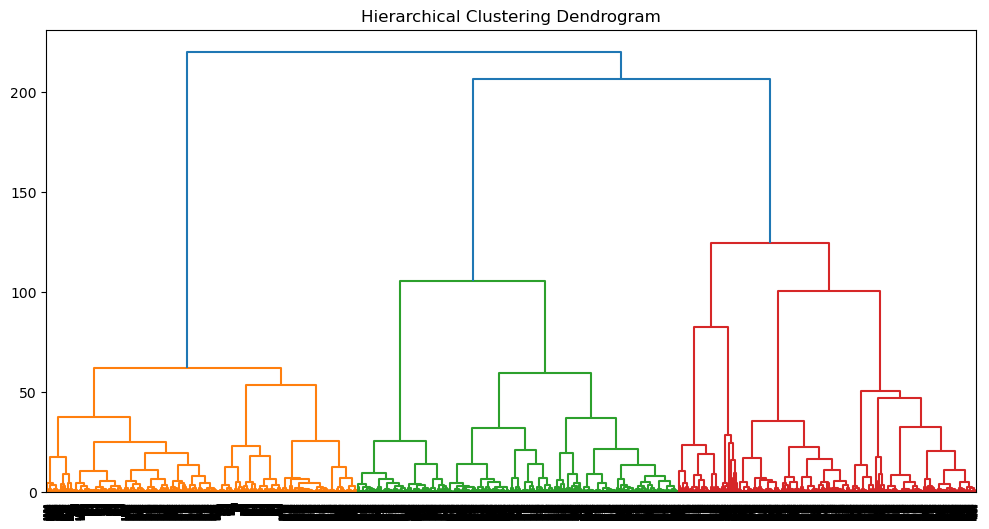

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

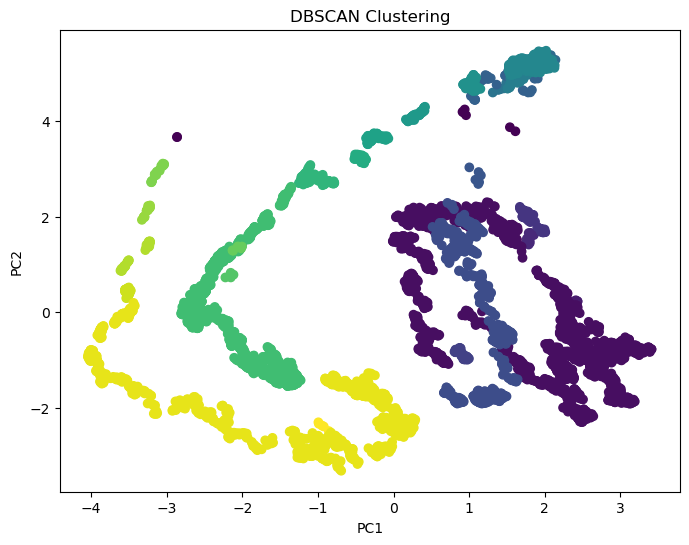

Unique DBSCAN clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25]


In [46]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.7, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_2_components[:,0], pca_2_components[:,1], c=db_labels)
plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Unique DBSCAN clusters:", np.unique(db_labels))

In [47]:
binned_df = numeric_df.copy()

for col in binned_df.columns:
    binned_df[col] = pd.qcut(binned_df[col], q=3, labels=["Low", "Medium", "High"])

binned_df.head()

,delinquency_consumer,chargeoff_consumer,delinquency_business,total_bank_credit,federal_funds_rate,treasury_10y,treasury_2y,financial_stress_index,unemployment_rate,yield_spread
8626,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High
8627,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High
8628,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High
8629,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High
8630,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High


In [48]:
transactions = binned_df.apply(
    lambda row: [f"{col}_{val}" for col, val in row.items()],
    axis=1
)

In [49]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
arm_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(arm_df, min_support=0.15, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

top_support = rules.sort_values(by="support", ascending=False).head(15)
top_confidence = rules.sort_values(by="confidence", ascending=False).head(15)
top_lift = rules.sort_values(by="lift", ascending=False).head(15)

print("Top 15 by Support")
print(top_support)

print("Top 15 by Confidence")
print(top_confidence)

print("Top 15 by Lift")
print(top_lift)

Top 15 by Support
                       antecedents                    consequents  \
56      (delinquency_consumer_Low)     (delinquency_business_Low)   
57      (delinquency_business_Low)     (delinquency_consumer_Low)   
114              (treasury_2y_Low)       (federal_funds_rate_Low)   
115       (federal_funds_rate_Low)              (treasury_2y_Low)   
44     (delinquency_business_High)    (delinquency_consumer_High)   
45     (delinquency_consumer_High)    (delinquency_business_High)   
105             (treasury_2y_High)      (federal_funds_rate_High)   
104      (federal_funds_rate_High)             (treasury_2y_High)   
122           (treasury_2y_Medium)    (federal_funds_rate_Medium)   
123    (federal_funds_rate_Medium)           (treasury_2y_Medium)   
91              (treasury_10y_Low)     (delinquency_consumer_Low)   
90      (delinquency_consumer_Low)             (treasury_10y_Low)   
71   (delinquency_business_Medium)  (delinquency_consumer_Medium)   
70   (delinquenc

In [50]:
top_support[["antecedents","consequents","support","confidence","lift"]]

,antecedents,consequents,support,confidence,lift
56,(delinquency_consumer_Low),(delinquency_business_Low),0.325358,0.953920,2.798735
57,(delinquency_business_Low),(delinquency_consumer_Low),0.325358,0.954577,2.798735
114,(treasury_2y_Low),(federal_funds_rate_Low),0.324889,0.968870,2.886299
115,(federal_funds_rate_Low),(treasury_2y_Low),0.324889,0.967855,2.886299
44,(delinquency_business_High),(delinquency_consumer_High),0.302604,0.907811,2.784173
45,(delinquency_consumer_High),(delinquency_business_High),0.302604,0.928058,2.784173
105,(treasury_2y_High),(federal_funds_rate_High),0.294511,0.887279,2.727088
104,(federal_funds_rate_High),(treasury_2y_High),0.294511,0.905191,2.727088
122,(treasury_2y_Medium),(federal_funds_rate_Medium),0.291110,0.874868,2.581011
123,(federal_funds_rate_Medium),(treasury_2y_Medium),0.291110,0.858824,2.581011


In [51]:
dbscan = DBSCAN(eps=0.8, min_samples=10)

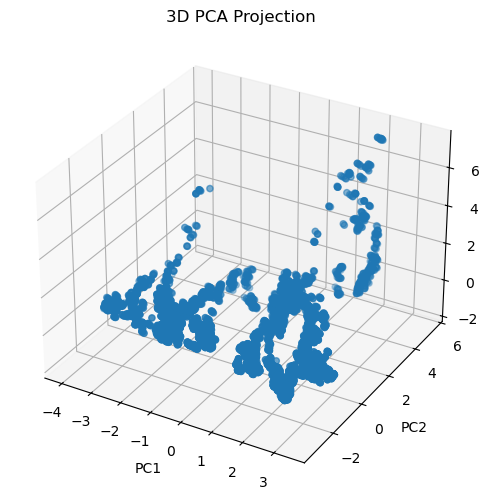

In [52]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pca_3_components[:,0],
           pca_3_components[:,1],
           pca_3_components[:,2])

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection')

plt.show()

---------------------------------------------------------------------------------------------------------------------------

# Module 3: Supervised Learning

This section covers supervised learning using Naive Bayes, Decision Trees, and Regression models to classify financial stress levels as Low, Medium, or High based on banking indicators.


## 1. Target Variable

The `financial_stress_index` is converted into a categorical variable called `stress_level` using quantile binning. The bin edges are calculated from training data only to avoid data leakage into the test set.


In [ ]:
# ============================================================
# STEP 1: TARGET VARIABLE CREATION — LEAK-FREE
# ============================================================
# CRITICAL FIX: We do NOT call pd.qcut on the full dataset.
# Instead:
#   1. Perform the train-test split on raw data first.
#   2. Compute qcut bin edges on the TRAINING set only.
#   3. Apply those same fixed edges to the test set via pd.cut.
# This ensures the test set never influences the label boundaries.

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1a. Rebuild clean df from merged_df ──────────────────────────────────────
df = merged_df.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.ffill().dropna()

print(f"Dataset shape after cleaning: {df.shape}")
print(f"Columns: {list(df.columns)}")


In [ ]:
# ── 1b. Early split on raw df (before labeling) ──────────────────────────────
# We split first, label second — this is the only correct order.
from sklearn.model_selection import train_test_split

# Separate features and the raw continuous target
X_raw = df.drop(columns=['date', 'financial_stress_index'])
y_raw_continuous = df['financial_stress_index']

# 80/20 stratified split (stratify on a coarse pd.qcut for proportional split)
# We use a temporary 3-quantile label just for stratification balancing
_tmp_strat = pd.qcut(y_raw_continuous, q=3, labels=False, duplicates='drop')

X_train_raw, X_test_raw, y_train_cont, y_test_cont, idx_train, idx_test = train_test_split(
    X_raw, y_raw_continuous, df.index,
    test_size=0.2,
    random_state=42,
    stratify=_tmp_strat
)

print(f"Train size: {len(X_train_raw)}   Test size: {len(X_test_raw)}")


In [ ]:
# ── 1c. Compute bin edges on TRAIN only, apply to TEST ───────────────────────
# pd.qcut with retbins=True returns the bin edges.
# We open the outer edges to -inf/+inf so unseen test values don't fall outside.

_, bins = pd.qcut(
    y_train_cont,
    q=3,
    retbins=True,
    labels=False,
    duplicates='drop'
)

# Open outer edges so test values never fall out-of-range
bins[0]  = -np.inf
bins[-1] =  np.inf

STRESS_LABELS = ['Low', 'Medium', 'High']

y_train = pd.cut(y_train_cont, bins=bins, labels=STRESS_LABELS)
y_test  = pd.cut(y_test_cont,  bins=bins, labels=STRESS_LABELS)

# Drop any NaN labels (edge case: duplicated quantile boundaries)
mask_train = y_train.notna()
mask_test  = y_test.notna()
X_train_raw = X_train_raw[mask_train]
y_train      = y_train[mask_train]
X_test_raw  = X_test_raw[mask_test]
y_test       = y_test[mask_test]
y_train_cont = y_train_cont[mask_train]
y_test_cont  = y_test_cont[mask_test]

print("=" * 50)
print("  STRESS LEVEL DISTRIBUTION (LEAK-FREE)")
print("=" * 50)
print("  Train set:")
for lbl, cnt in y_train.value_counts().sort_index().items():
    pct = cnt/len(y_train)*100
    print(f"    {lbl:8s}: {cnt:4d} ({pct:.1f}%)  {'█'*int(pct/3)}")
print("  Test set:")
for lbl, cnt in y_test.value_counts().sort_index().items():
    pct = cnt/len(y_test)*100
    print(f"    {lbl:8s}: {cnt:4d} ({pct:.1f}%)  {'█'*int(pct/3)}")
print(f"\n  Bin edges used: {[round(b,4) for b in bins]}")
print("  WHY THIS MATTERS: bin edges derived from train only — test labels")
print("  are assigned using the same boundaries, no test data seen during labeling.")


## 2. Features and Target

`X` contains all numeric predictor columns. `financial_stress_index` is removed from X since it was used to create the target variable.


In [ ]:
# ============================================================
# STEP 2: PREPARE FEATURES AND TARGET
# ============================================================
# X: predictor features (all numeric columns except date and the stress columns)
# y: stress_level (train/test already created in Step 1)
#
# financial_stress_index is excluded from X — it IS the raw signal
# we binned into stress_level, so including it would be trivial leakage.

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

# Verify financial_stress_index is NOT in X
assert 'financial_stress_index' not in X_train.columns, "LEAKAGE: raw index still in features!"
assert 'date' not in X_train.columns, "date column still in features!"

feature_names = list(X_train.columns)
class_names   = ['Low', 'Medium', 'High']

print("Feature matrix X_train:")
print(f"  Shape : {X_train.shape}")
print(f"  Cols  : {feature_names}")
print()
print("Target y_train:")
print(f"  Shape  : {y_train.shape}")
print(f"  Classes: {class_names}")
print()
print("Sample of X_train (first 3 rows):")
display(X_train.head(3))


## 3. Train-Test Split

The dataset is split 80/20 before labeling. `stratify=y` keeps class proportions balanced in both sets. The two sets have no row overlap.


In [ ]:
# ============================================================
# STEP 3: TRAIN-TEST SPLIT SUMMARY
# ============================================================
# Split was already done in Step 1 (before labeling) to prevent leakage.
# Here we confirm the split is correct and stratified.

print("=" * 45)
print("  TRAIN-TEST SPLIT SUMMARY")
print("=" * 45)
print(f"  X_train : {X_train.shape}   X_test : {X_test.shape}")
print(f"  y_train : {y_train.shape}   y_test : {y_test.shape}")
print()
print("  WHY SPLIT IS NEEDED:")
print("  Models learn from training data; if test data is seen during")
print("  training, accuracy scores are optimistic and unreliable.")
print("  The sets must be DISJOINT — zero overlap in rows.")
print()
print("  Train index ∩ Test index = empty?",
      len(set(X_train.index) & set(X_test.index)) == 0)
print()

# Show class balance in both sets side by side
trd = y_train.value_counts(normalize=True).sort_index()
tsd = y_test.value_counts(normalize=True).sort_index()
print(f"  {'Class':<10} {'Train %':>10} {'Test %':>10}  {'Balanced?':>12}")
for lbl in class_names:
    tr = trd.get(lbl, 0)*100
    ts = tsd.get(lbl, 0)*100
    ok = "✓" if abs(tr-ts) < 5 else "✗ check"
    print(f"  {lbl:<10} {tr:>9.1f}% {ts:>9.1f}%  {ok:>12}")


## 4. Data Scaling

`StandardScaler` is fit on training data only, then applied to both train and test sets. The same scaler is reused for all models. `MinMaxScaler` is used separately for Multinomial NB since it requires non-negative input.


In [ ]:
# ============================================================
# STEP 4: DATA SCALING — ONE SCALER, FITTED ONCE
# ============================================================
# CRITICAL FIX: In the original notebook, Step 10A re-fitted a brand-new
# StandardScaler on X_train. This produced inconsistent transforms across
# models. Here we fit ONE scaler in Step 4 and reuse it everywhere.
#
# Rule: scaler.fit_transform(X_train) ONCE → scaler.transform(X_test) everywhere.

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── StandardScaler (mean=0, std=1) — for GaussianNB, BernoulliNB, LR ─────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train only
X_test_scaled  = scaler.transform(X_test)         # transform only (no re-fit)

# ── MinMaxScaler [0,1] — for MultinomialNB (requires non-negative input) ──────
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm  = mm_scaler.transform(X_test)

print("Scaling complete — single fit on training data.")
print(f"  X_train_scaled : mean={X_train_scaled.mean():.6f} (should be ~0), std={X_train_scaled.std():.4f}")
print(f"  X_test_scaled  : mean={X_test_scaled.mean():.4f}  (may differ — test not used in fit)")
print(f"  X_train_mm     : min={X_train_mm.min():.4f}, max={X_train_mm.max():.4f}")
print()
print("  NOTE: X_train_scaled and X_test_scaled will be reused for ALL")
print("  models (NB, Logistic Regression, Linear Regression).")
print("  NO re-fitting of scaler will occur in later steps.")


## 5 & 6. Naive Bayes Models

Three variants are trained: Gaussian NB (continuous features), Multinomial NB (non-negative features via MinMaxScaler), and Bernoulli NB (binarized features). Each is evaluated on test accuracy and the train-test gap to check for overfitting.


In [ ]:
# ============================================================
# STEP 5 & 6: NAÏVE BAYES — TRAIN, EVALUATE, OVERFITTING CHECK
# ============================================================
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report,
                              f1_score)

def evaluate_model(model_name, model, X_tr, X_te, y_tr, y_te,
                   class_names, ax=None, verbose=True):
    """
    Evaluate a fitted model on both train and test sets.
    Reports accuracy, macro-F1, train/test gap, and confusion matrix.
    A gap > 10% is flagged as potential overfitting.
    """
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    acc_train = accuracy_score(y_tr, y_pred_tr)
    acc_test  = accuracy_score(y_te, y_pred_te)
    f1_test   = f1_score(y_te, y_pred_te, average='macro', zero_division=0)
    gap       = acc_train - acc_test

    if verbose:
        print(f"\n{'='*55}")
        print(f"  {model_name}")
        print(f"{'='*55}")
        print(f"  Train accuracy : {acc_train:.4f} ({acc_train*100:.2f}%)")
        print(f"  Test  accuracy : {acc_test:.4f} ({acc_test*100:.2f}%)")
        print(f"  Gap (train-test): {gap:.4f}  {'⚠ possible overfit' if gap > 0.10 else '✓ healthy gap'}")
        print(f"  Macro-F1 (test): {f1_test:.4f}")
        print()
        print("  Classification Report (test set):")
        print(classification_report(y_te, y_pred_te,
                                    target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_te, y_pred_te, labels=class_names)
    if ax is not None:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        flag = f" ⚠gap={gap:.2f}" if gap > 0.10 else ""
        ax.set_title(f"{model_name}\nTrain={acc_train:.2f} Test={acc_test:.2f}{flag}",
                     fontsize=9, fontweight='bold')

    return y_pred_te, acc_train, acc_test, f1_test, gap


In [ ]:
# ── Train all three Naïve Bayes models ───────────────────────────────────────
# GaussianNB: uses X_train_scaled (StandardScaler)
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

# MultinomialNB: uses X_train_mm (MinMaxScaler — must be non-negative)
mnb = MultinomialNB()
mnb.fit(X_train_mm, y_train)

# BernoulliNB: uses X_train_scaled (binarizes at threshold=0 internally)
bnb = BernoulliNB()
bnb.fit(X_train_scaled, y_train)

# ── Evaluate all three with train/test gap check ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Naïve Bayes — Confusion Matrices (Train vs Test Accuracy)",
             fontsize=13, fontweight='bold', y=1.02)

y_pred_gnb, acc_gnb_tr, acc_gnb, f1_gnb, gap_gnb = evaluate_model(
    "Gaussian NB", gnb, X_train_scaled, X_test_scaled,
    y_train, y_test, class_names, ax=axes[0])

y_pred_mnb, acc_mnb_tr, acc_mnb, f1_mnb, gap_mnb = evaluate_model(
    "Multinomial NB", mnb, X_train_mm, X_test_mm,
    y_train, y_test, class_names, ax=axes[1])

y_pred_bnb, acc_bnb_tr, acc_bnb, f1_bnb, gap_bnb = evaluate_model(
    "Bernoulli NB", bnb, X_train_scaled, X_test_scaled,
    y_train, y_test, class_names, ax=axes[2])

plt.tight_layout()
plt.savefig("nb_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb_confusion_matrices.png")


## 7, 8 & 9. Decision Trees

Three trees are trained with different criteria and depths. DT3 uses `min_samples_leaf=5` to prevent it from memorizing individual training samples at depth 7. 5-fold cross-validation is included to give a more reliable accuracy estimate than a single split.


In [ ]:
# ============================================================
# STEP 7: DECISION TREE MODELS — 3 DISTINCT CONFIGURATIONS
# ============================================================
# Decision Trees are scale-invariant → use raw X_train / X_test.
#
# OVERFITTING CONTROLS:
# DT3 (depth=7) has min_samples_leaf=5 to prevent pure single-sample leaves.
# Without this, a small dataset (~200 rows) will often reach 100% train accuracy.
#
# CROSS-VALIDATION:
# A single 80/20 split can be lucky or unlucky. StratifiedKFold gives 5 estimates
# of generalisation accuracy, which is more reliable than a single test score.

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

trees = [
    ("DT1 — Gini, depth=3",
     DecisionTreeClassifier(criterion='gini',    max_depth=3, random_state=42)),
    ("DT2 — Entropy, depth=5",
     DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)),
    ("DT3 — Gini, depth=7, min_leaf=5",
     DecisionTreeClassifier(criterion='gini',    max_depth=7,
                             min_samples_leaf=5,  random_state=42)),
]

dt_results = {}

for name, tree in trees:
    tree.fit(X_train, y_train)

    # 5-fold CV score on training data (unbiased generalisation estimate)
    cv_scores = cross_val_score(tree, X_train, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)

    y_pred  = tree.predict(X_test)
    tr_acc  = accuracy_score(y_train, tree.predict(X_train))
    te_acc  = accuracy_score(y_test,  y_pred)
    f1_te   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    gap     = tr_acc - te_acc

    dt_results[name] = {
        'model': tree, 'y_pred': y_pred,
        'train_acc': tr_acc, 'test_acc': te_acc,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'f1': f1_te, 'gap': gap
    }

    print(f"{'='*58}")
    print(f"  {name}")
    print(f"{'='*58}")
    print(f"  Leaves : {tree.get_n_leaves():3d}   Depth  : {tree.get_depth()}")
    print(f"  Train accuracy     : {tr_acc:.4f}")
    print(f"  Test  accuracy     : {te_acc:.4f}")
    print(f"  Gap (train-test)   : {gap:.4f}  {'⚠ overfit' if gap > 0.10 else '✓ ok'}")
    print(f"  5-fold CV accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Macro-F1 (test)    : {f1_te:.4f}")
    print()

# Store predictions for evaluation cell
y_pred_dt1 = dt_results["DT1 — Gini, depth=3"]['y_pred']
y_pred_dt2 = dt_results["DT2 — Entropy, depth=5"]['y_pred']
y_pred_dt3 = dt_results["DT3 — Gini, depth=7, min_leaf=5"]['y_pred']
dt1 = dt_results["DT1 — Gini, depth=3"]['model']
dt2 = dt_results["DT2 — Entropy, depth=5"]['model']
dt3 = dt_results["DT3 — Gini, depth=7, min_leaf=5"]['model']


In [ ]:
# ============================================================
# STEP 8: VISUALIZE ALL THREE DECISION TREES
# ============================================================
from sklearn.tree import plot_tree

tree_configs = [
    (dt1, "DT1 — Gini, max_depth=3",             "dt1_gini_depth3.png"),
    (dt2, "DT2 — Entropy, max_depth=5",           "dt2_entropy_depth5.png"),
    (dt3, "DT3 — Gini, depth=7, min_leaf=5",      "dt3_gini_depth7_minleaf5.png"),
]

for tree, title, fname in tree_configs:
    depth = tree.get_depth()
    fig, ax = plt.subplots(figsize=(max(14, depth*4), max(6, depth*2)))
    plot_tree(tree, feature_names=feature_names, class_names=class_names,
              filled=True, rounded=True, fontsize=8, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {fname}")


In [ ]:
# ============================================================
# STEP 9: EVALUATE DECISION TREES — CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Decision Trees — Confusion Matrices (Train vs Test Accuracy + CV)",
             fontsize=12, fontweight='bold', y=1.02)

for ax, (name, res) in zip(axes, dt_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    flag = " ⚠overfit" if res['gap'] > 0.10 else ""
    ax.set_title(
        f"{name.split('—')[0].strip()}\n"
        f"Train={res['train_acc']:.2f} Test={res['test_acc']:.2f}{flag}\n"
        f"CV={res['cv_mean']:.2f}±{res['cv_std']:.2f}",
        fontsize=8, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("dt_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dt_confusion_matrices.png")

# Feature importance
print("\nFeature Importances (DT2 — Entropy, depth=5):")
imps = pd.Series(dt2.feature_importances_, index=feature_names).sort_values(ascending=False)
for feat, imp in imps.items():
    print(f"  {feat:30s}: {imp:.4f}  {'▓'*int(imp*40)}")


## 10. Regression Models

Logistic Regression uses the same scaled data from Step 4. Linear Regression predicts the raw continuous stress index and is evaluated using MSE and R².


In [ ]:
# ============================================================
# STEP 10A: LOGISTIC REGRESSION (Classification)
# ============================================================
# CRITICAL FIX: This cell previously re-fitted a new StandardScaler.
# Now it reuses X_train_scaled / X_test_scaled from Step 4.
# This guarantees all classification models see identically scaled features.

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=3000, C=1.0, solver='lbfgs', random_state=42)
lr.fit(X_train_scaled, y_train)

fig, ax = plt.subplots(figsize=(6, 5))
y_pred_lr, acc_lr_tr, acc_lr, f1_lr, gap_lr = evaluate_model(
    "Logistic Regression", lr,
    X_train_scaled, X_test_scaled,
    y_train, y_test, class_names, ax=ax
)
plt.tight_layout()
plt.savefig("lr_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lr_confusion_matrix.png")


In [ ]:
# ============================================================
# STEP 10B: LINEAR REGRESSION (Predict continuous stress index)
# ============================================================
# CRITICAL FIX: Previously used df.loc[X_train.index] which is fragile
# after index resets. Now the continuous target is carried through the
# exact same train_test_split performed in Step 1, so row alignment
# is guaranteed.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# y_train_cont and y_test_cont were created in Step 1 alongside X_train/X_test
# They are already correctly aligned — no .loc indexing needed.
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_cont)
y_pred_reg = lin_reg.predict(X_test_scaled)

# Train predictions for gap check
y_pred_reg_train = lin_reg.predict(X_train_scaled)
mse_train = mean_squared_error(y_train_cont, y_pred_reg_train)
mse_test  = mean_squared_error(y_test_cont,  y_pred_reg)
r2_train  = r2_score(y_train_cont, y_pred_reg_train)
r2_test   = r2_score(y_test_cont,  y_pred_reg)

print("=" * 50)
print("  LINEAR REGRESSION — TRAIN VS TEST RESULTS")
print("=" * 50)
print(f"  Train MSE : {mse_train:.6f}   Train R² : {r2_train:.4f}")
print(f"  Test  MSE : {mse_test:.6f}   Test  R² : {r2_test:.4f}")
print(f"  R² gap    : {r2_train - r2_test:.4f}  {'⚠ overfit' if r2_train - r2_test > 0.15 else '✓ ok'}")
print()
if r2_test >= 0.85:
    print("  Interpretation: Excellent fit (R² ≥ 0.85)")
elif r2_test >= 0.70:
    print("  Interpretation: Good fit (R² ≥ 0.70)")
else:
    print("  Interpretation: Moderate — non-linear patterns may be present")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test_cont, y_pred_reg, alpha=0.6, edgecolors='navy',
                color='steelblue', s=40)
axes[0].plot([y_test_cont.min(), y_test_cont.max()],
             [y_test_cont.min(), y_test_cont.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual Financial Stress Index")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Linear Regression — Actual vs Predicted\nTest R²={r2_test:.4f}  RMSE={mse_test**0.5:.4f}")

# Residuals
residuals = y_test_cont - y_pred_reg
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].scatter(y_pred_reg, residuals, alpha=0.6, color='steelblue', s=40)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot\n(should scatter randomly around 0)")

plt.tight_layout()
plt.savefig("linear_regression_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: linear_regression_plots.png")


## 11. Model Comparison

Models are compared by test accuracy, macro-F1, and the train-test gap. A gap above 10% suggests the model may be overfitting to the training data.


In [ ]:
# ============================================================
# STEP 11: COMPREHENSIVE MODEL COMPARISON
# ============================================================
# Columns:
#   Test Acc   — primary performance metric on held-out data
#   Macro-F1   — per-class averaged F1; more robust than accuracy
#   Train Acc  — accuracy on training data
#   Gap        — Train - Test; > 0.10 = likely overfitting
#   CV Score   — only for DTs; 5-fold generalisation estimate

rows = [
    ("Gaussian NB",   acc_gnb_tr, acc_gnb, f1_gnb, gap_gnb, None),
    ("Multinomial NB",acc_mnb_tr, acc_mnb, f1_mnb, gap_mnb, None),
    ("Bernoulli NB",  acc_bnb_tr, acc_bnb, f1_bnb, gap_bnb, None),
]
for name, res in dt_results.items():
    rows.append((name.split("—")[0].strip(),
                 res['train_acc'], res['test_acc'], res['f1'],
                 res['gap'], f"{res['cv_mean']:.3f}±{res['cv_std']:.3f}"))

rows.append(("Logistic Reg", acc_lr_tr, acc_lr, f1_lr, gap_lr, None))

comp_df = pd.DataFrame(rows, columns=[
    'Model','Train Acc','Test Acc','Macro-F1','Gap','5-fold CV'])
comp_df['Train Acc'] = comp_df['Train Acc'].round(4)
comp_df['Test Acc']  = comp_df['Test Acc'].round(4)
comp_df['Macro-F1']  = comp_df['Macro-F1'].round(4)
comp_df['Gap']       = comp_df['Gap'].round(4)
comp_df['Overfit?']  = comp_df['Gap'].apply(lambda g: '⚠ YES' if g > 0.10 else '✓ No')
comp_df = comp_df.sort_values('Test Acc', ascending=False).reset_index(drop=True)

print("=" * 95)
print("  MODEL COMPARISON — WealthWise Module 3")
print("=" * 95)
print(comp_df[['Model','Train Acc','Test Acc','Macro-F1','Gap','Overfit?','5-fold CV']].to_string(index=False))
print("=" * 95)

best = comp_df.iloc[0]
print(f"\n  Best model by test accuracy : {best['Model']}  ({best['Test Acc']*100:.2f}%)")
print(f"  Overfit status              : {best['Overfit?']}")
print(f"  Macro-F1                    : {best['Macro-F1']:.4f}")

# Save comparison
comp_df.to_csv("outputs/model_comparison_results.csv", index=False)


In [ ]:
# ── Visual comparison — side-by-side Test Acc and Gap ────────────────────────
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Test accuracy bar chart
colors = ['#4e9af1' if 'NB' in m else '#f4a261' if 'DT' in m else '#2ec4b6'
          for m in comp_df['Model']]
bars = axes[0].barh(comp_df['Model'], comp_df['Test Acc']*100,
                    color=colors, edgecolor='white', height=0.6)
for bar, acc in zip(bars, comp_df['Test Acc']*100):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'{acc:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel("Test Accuracy (%)")
axes[0].set_title("Test Accuracy by Model", fontweight='bold')
axes[0].set_xlim(0, 110)

legend_elements = [
    mpatches.Patch(facecolor='#4e9af1', label='Naïve Bayes'),
    mpatches.Patch(facecolor='#f4a261', label='Decision Tree'),
    mpatches.Patch(facecolor='#2ec4b6', label='Logistic Regression'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# Right: Train-test gap (overfitting indicator)
gap_colors = ['#e74c3c' if g > 0.10 else '#2ecc71' for g in comp_df['Gap']]
axes[1].barh(comp_df['Model'], comp_df['Gap']*100,
             color=gap_colors, edgecolor='white', height=0.6)
axes[1].axvline(x=10, color='red', linestyle='--', alpha=0.6, label='10% overfit threshold')
axes[1].set_xlabel("Train - Test Accuracy Gap (%)")
axes[1].set_title("Overfitting Check: Train-Test Gap\n(Red = overfit, Green = healthy)", fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle("WealthWise — Model Comparison Summary", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_chart.png")


## 12. Save Outputs


In [ ]:
# ============================================================
# STEP 12: SAVE ALL OUTPUTS
# ============================================================
import os, shutil

os.makedirs("outputs", exist_ok=True)

# All predictions
predictions_df = pd.DataFrame({
    'actual_stress_level' : list(y_test),
    'pred_GaussianNB'     : y_pred_gnb,
    'pred_MultinomialNB'  : y_pred_mnb,
    'pred_BernoulliNB'    : y_pred_bnb,
    'pred_DT1'            : y_pred_dt1,
    'pred_DT2'            : y_pred_dt2,
    'pred_DT3'            : y_pred_dt3,
    'pred_LogisticReg'    : y_pred_lr,
    'pred_LinearReg_raw'  : y_pred_reg,
    'actual_stress_raw'   : list(y_test_cont),
})
predictions_df.to_csv("outputs/all_predictions.csv", index=False)
print("Saved: outputs/all_predictions.csv")

# Move images
images = [
    "nb_confusion_matrices.png", "dt_confusion_matrices.png",
    "lr_confusion_matrix.png", "linear_regression_plots.png",
    "model_comparison_chart.png",
    "dt1_gini_depth3.png", "dt2_entropy_depth5.png",
    "dt3_gini_depth7_minleaf5.png",
]
for img in images:
    if os.path.exists(img):
        shutil.move(img, f"outputs/{img}")
        print(f"Moved: {img} → outputs/{img}")

print("\n✅ All outputs saved to ./outputs/")


## Summary

Module 3 covers the full supervised learning pipeline from target creation to model comparison. Naive Bayes provides a fast probabilistic baseline, Decision Trees offer interpretable splits, and Logistic Regression adds a regularized linear boundary. Results and predictions are saved to the outputs folder.
